# S&P 500 Deep Analysis: 25 Years of Market Data + LSTM Forecasting

25 years of daily stock data for ~500 companies. In this notebook we explore market trends, sector dynamics, volatility patterns, and build an LSTM neural network to forecast stock prices.

**What's inside:**

1. **Market overview** — index performance, bull/bear cycles, trading volume trends
2. **Sector analysis** — which sectors won each decade, rotation patterns
3. **Volatility** — rolling volatility, VIX proxy, crash detection
4. **Correlation heatmaps** — sector correlations, diversification opportunities
5. **Individual stock analysis** — top performers, worst performers, risk-return scatter
6. **Technical indicators** — moving averages, RSI, Bollinger Bands
7. **LSTM neural network** — predicting next-day close price

Dataset: [S&P 500 Stocks — 25 Years Daily Updated](https://www.kaggle.com/datasets/darkmatternet/sp500-stocks-daily-updated)

In [1]:
!pip install tensorflow -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
from datetime import datetime, timedelta

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 12,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

BLUE, RED, GREEN, ORANGE, PURPLE = "#2196F3", "#F44336", "#4CAF50", "#FF9800", "#9C27B0"
COLORS = ["#2196F3", "#F44336", "#4CAF50", "#FF9800", "#9C27B0",
          "#00BCD4", "#E91E63", "#8BC34A", "#FFC107", "#607D8B", "#795548"]

2026-03-29 17:56:44.678525: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774807005.028230      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774807005.132131      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774807006.006073      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774807006.006120      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774807006.006123      17 computation_placer.cc:177] computation placer alr

## 1. Load Data

In [3]:
import os
for root, dirs, files in os.walk('/kaggle/input/'):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/darkmatternet/s-and-p-500-stocks-25-years-of-data-updated-daily/sp500_stocks.csv
/kaggle/input/datasets/darkmatternet/s-and-p-500-stocks-25-years-of-data-updated-daily/sp500_companies.csv


In [4]:
companies = pd.read_csv("/kaggle/input/datasets/darkmatternet/s-and-p-500-stocks-25-years-of-data-updated-daily/sp500_companies.csv")
stocks = pd.read_csv("/kaggle/input/datasets/darkmatternet/s-and-p-500-stocks-25-years-of-data-updated-daily/sp500_stocks.csv", parse_dates=["date"])

print(f"Companies: {companies.shape}")
print(f"Stock data: {stocks.shape[0]:,} rows, {stocks['symbol'].nunique()} tickers")
print(f"Date range: {stocks['date'].min().date()} to {stocks['date'].max().date()}")
print(f"Sectors: {companies['sector'].nunique()}")
stocks.head()

Companies: (503, 7)
Stock data: 2,909,982 rows, 503 tickers
Date range: 2000-01-03 to 2026-03-27
Sectors: 11


,date,open,high,low,close,volume,symbol
0,2000-01-03,47.071068,47.183143,40.271914,43.036407,4674353.0,A
1,2000-01-04,40.720196,41.168494,38.702866,39.748890,4765083.0,A
2,2000-01-05,39.599454,39.748888,36.050450,37.283260,5758642.0,A
3,2000-01-06,36.834972,37.059121,34.742923,35.863663,2534434.0,A
4,2000-01-07,35.303308,39.412688,35.265952,38.852318,2819626.0,A


In [5]:
# Merge sector info into stock data
stocks = stocks.merge(companies[["symbol", "sector", "company"]], on="symbol", how="left")

---

## 2. Market Overview

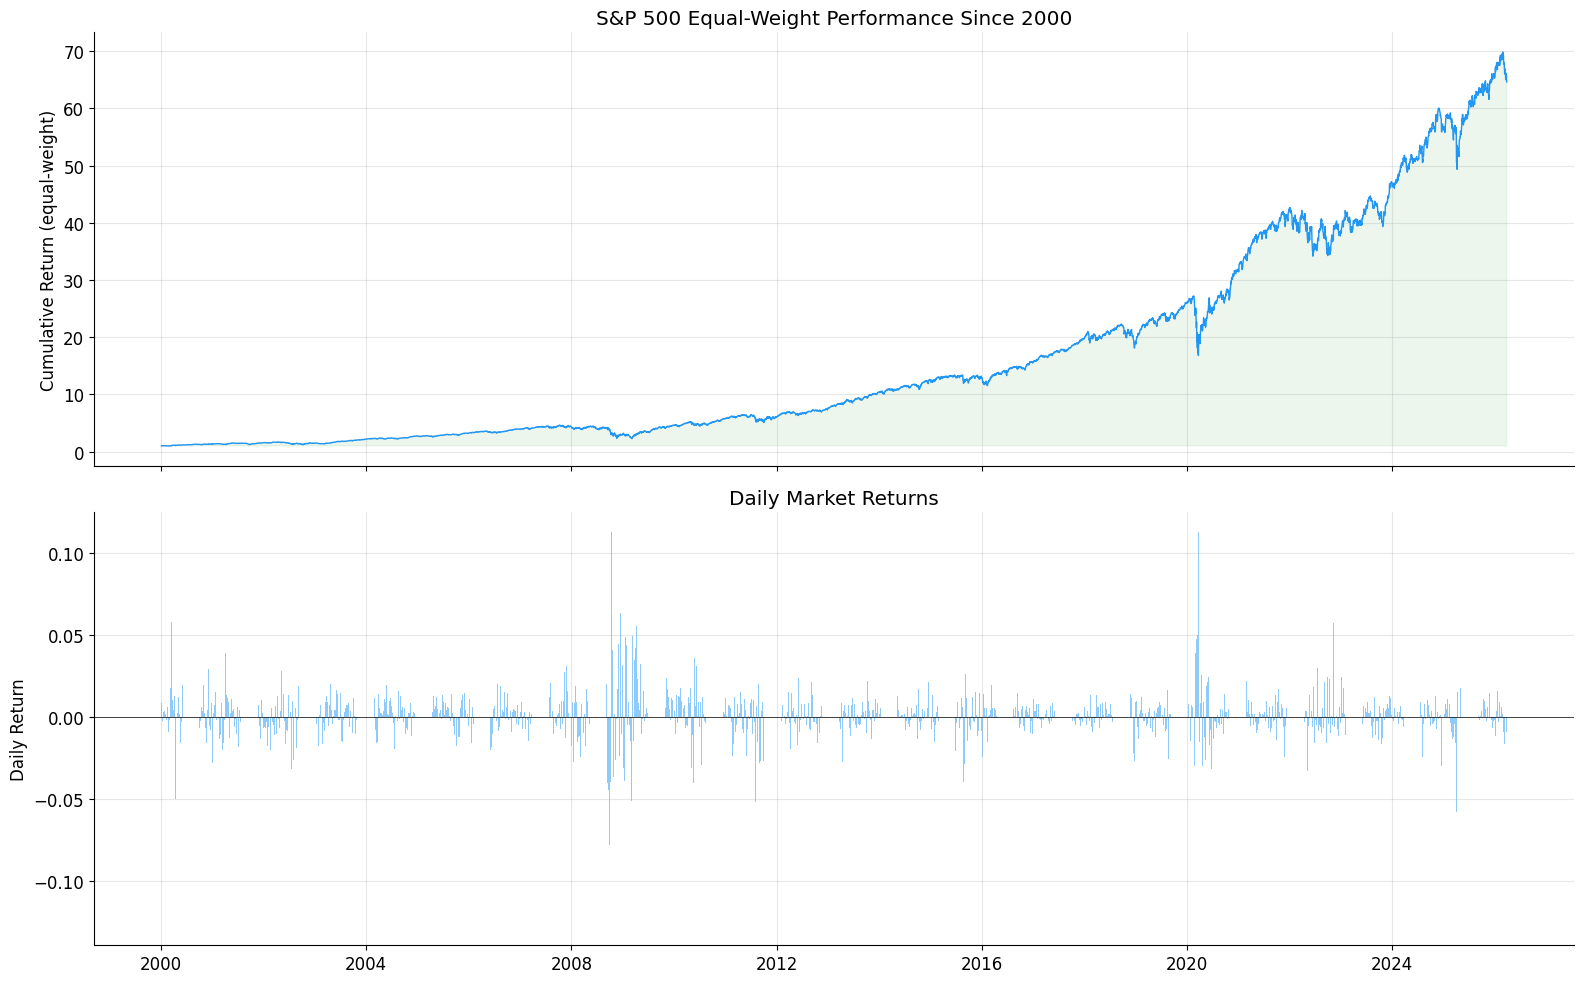

In [6]:
# Build a simple equal-weight S&P 500 proxy using daily mean return
daily_returns = stocks.pivot_table(index="date", columns="symbol", values="close").pct_change()
market_return = daily_returns.mean(axis=1)
market_cumulative = (1 + market_return).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Cumulative return
axes[0].plot(market_cumulative.index, market_cumulative.values, color=BLUE, linewidth=1)
axes[0].set_ylabel("Cumulative Return (equal-weight)")
axes[0].set_title("S&P 500 Equal-Weight Performance Since 2000")
axes[0].fill_between(market_cumulative.index, 1, market_cumulative.values,
                     where=market_cumulative.values >= 1, alpha=0.1, color=GREEN)
axes[0].fill_between(market_cumulative.index, 1, market_cumulative.values,
                     where=market_cumulative.values < 1, alpha=0.1, color=RED)

# Daily returns
axes[1].bar(market_return.index, market_return.values, width=1, color=BLUE, alpha=0.5)
axes[1].set_ylabel("Daily Return")
axes[1].set_title("Daily Market Returns")
axes[1].axhline(y=0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

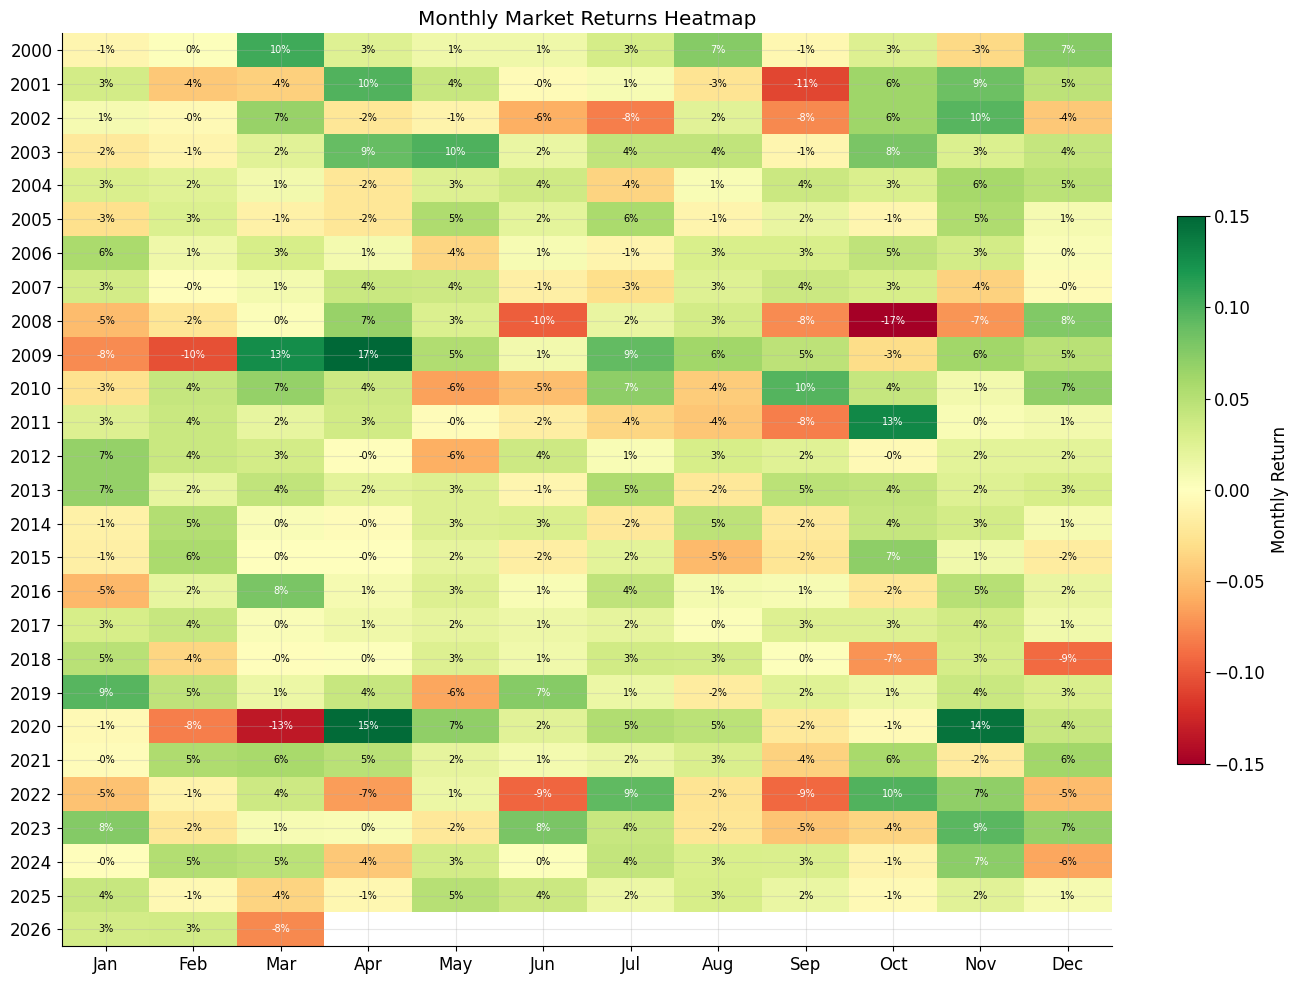

In [7]:
# Annual returns heatmap
market_return_df = market_return.to_frame("return")
market_return_df["year"] = market_return_df.index.year
market_return_df["month"] = market_return_df.index.month

monthly_returns = market_return_df.groupby(["year", "month"])["return"].sum().unstack()
monthly_returns.columns = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                            "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(monthly_returns.values, cmap="RdYlGn", aspect="auto", vmin=-0.15, vmax=0.15)
ax.set_yticks(range(len(monthly_returns.index)))
ax.set_yticklabels(monthly_returns.index)
ax.set_xticks(range(12))
ax.set_xticklabels(monthly_returns.columns)
ax.set_title("Monthly Market Returns Heatmap")
plt.colorbar(im, ax=ax, label="Monthly Return", shrink=0.6)

# Annotate cells
for i in range(len(monthly_returns.index)):
    for j in range(12):
        val = monthly_returns.iloc[i, j]
        if not np.isnan(val):
            color = "white" if abs(val) > 0.07 else "black"
            ax.text(j, i, f"{val:.0%}", ha="center", va="center", fontsize=7, color=color)

plt.tight_layout()
plt.show()

---

## 3. Sector Analysis

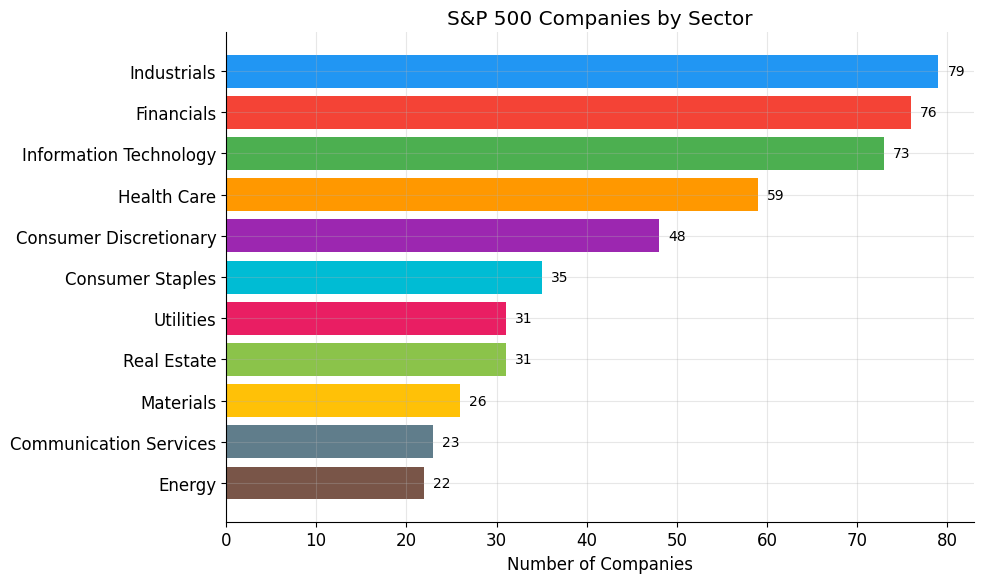

In [8]:
# Sector breakdown
sector_counts = companies["sector"].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(sector_counts)), sector_counts.values, color=COLORS[:len(sector_counts)])
ax.set_yticks(range(len(sector_counts)))
ax.set_yticklabels(sector_counts.index)
ax.set_xlabel("Number of Companies")
ax.set_title("S&P 500 Companies by Sector")
ax.invert_yaxis()

for bar, val in zip(bars, sector_counts.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, str(val),
            va="center", fontsize=10)

plt.tight_layout()
plt.show()

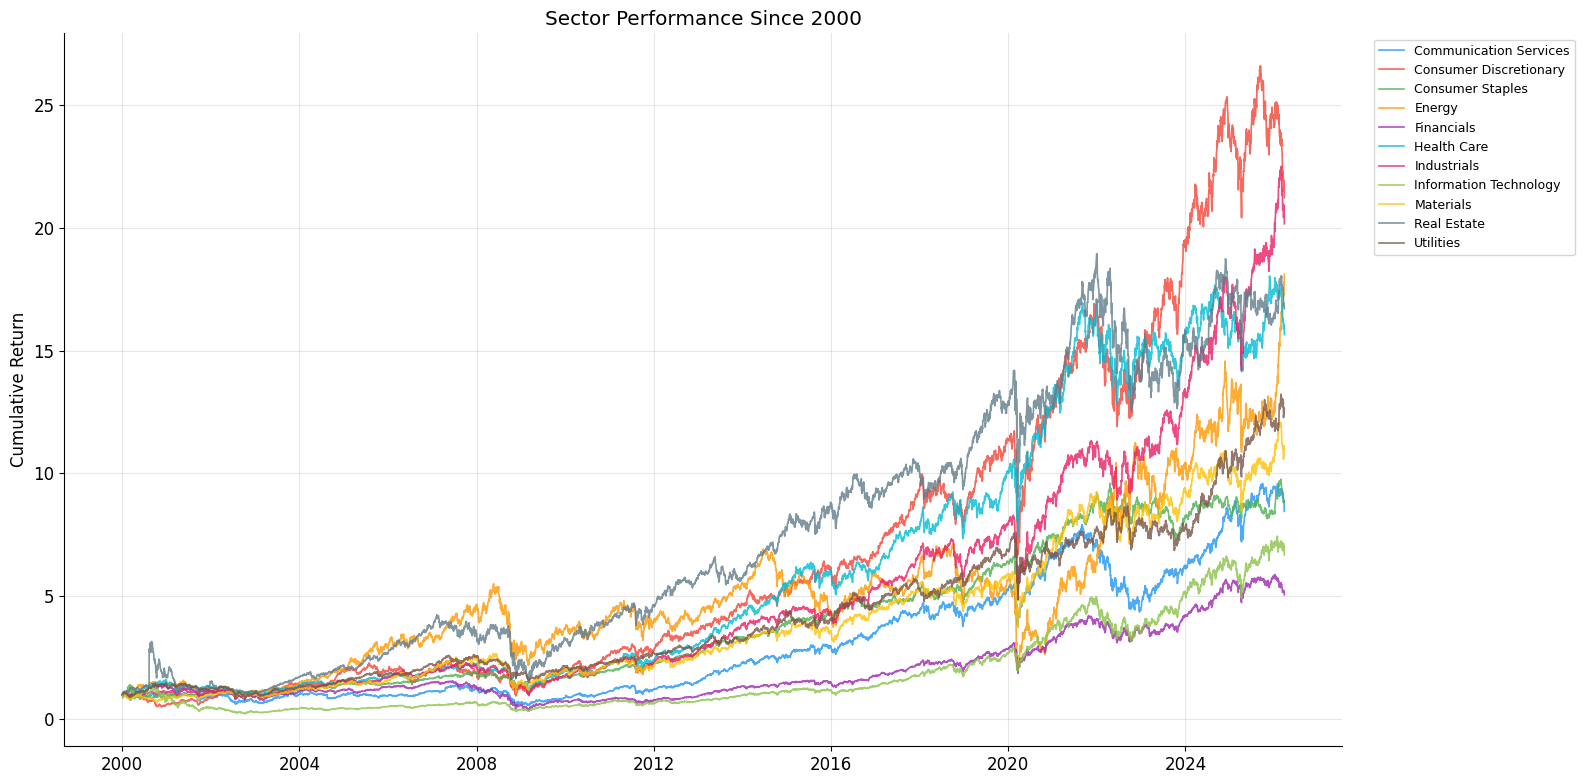

In [9]:
# Sector cumulative returns over time
sector_returns = stocks.groupby(["date", "sector"])["close"].mean().unstack()
sector_returns = sector_returns.pct_change()
sector_cumulative = (1 + sector_returns).cumprod()

fig, ax = plt.subplots(figsize=(16, 8))
for i, col in enumerate(sector_cumulative.columns):
    ax.plot(sector_cumulative.index, sector_cumulative[col],
            linewidth=1.2, alpha=0.8, label=col, color=COLORS[i % len(COLORS)])

ax.set_ylabel("Cumulative Return")
ax.set_title("Sector Performance Since 2000")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

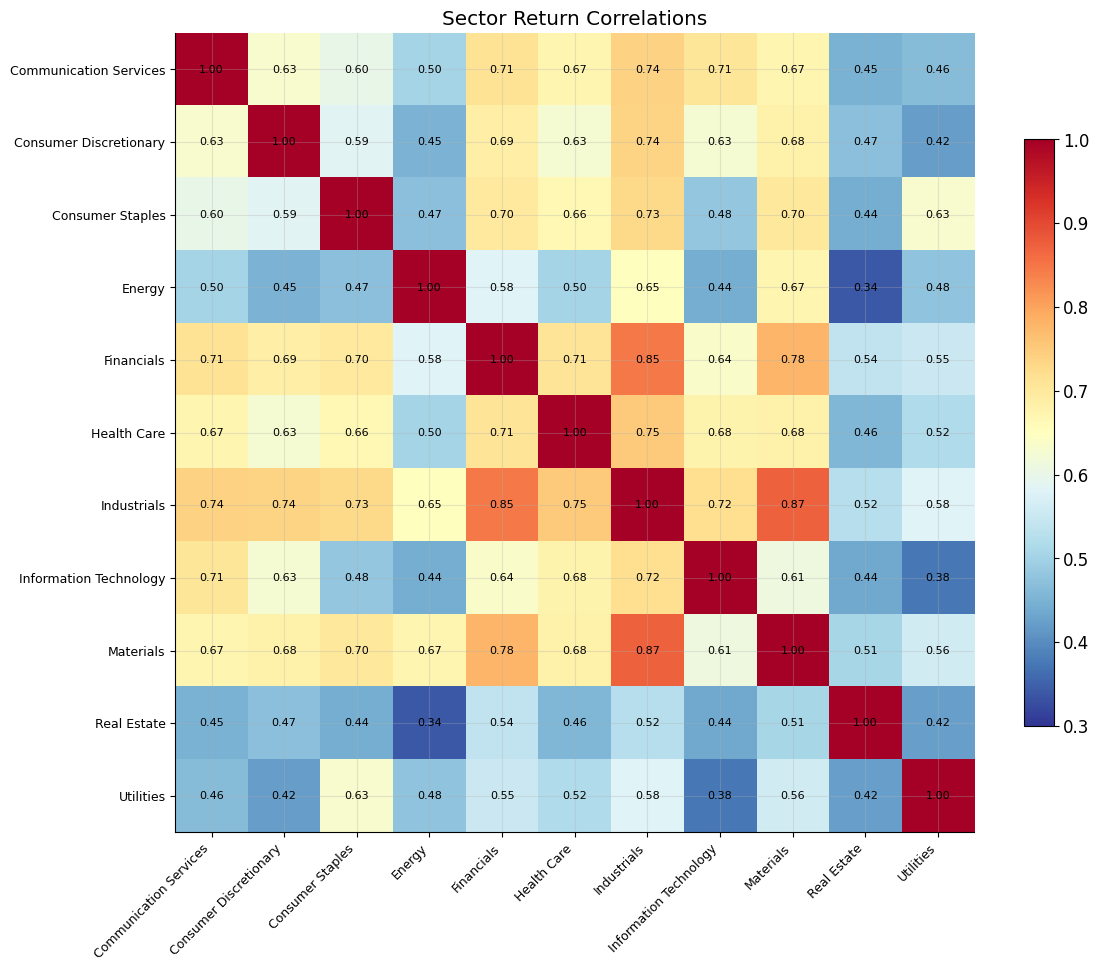

In [10]:
# Sector correlation heatmap
sector_corr = sector_returns.corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(sector_corr.values, cmap="RdYlBu_r", vmin=0.3, vmax=1.0)
ax.set_xticks(range(len(sector_corr.columns)))
ax.set_xticklabels(sector_corr.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(sector_corr.index)))
ax.set_yticklabels(sector_corr.index, fontsize=9)
ax.set_title("Sector Return Correlations")
plt.colorbar(im, ax=ax, shrink=0.7)

for i in range(len(sector_corr)):
    for j in range(len(sector_corr)):
        ax.text(j, i, f"{sector_corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

---

## 4. Volatility Analysis

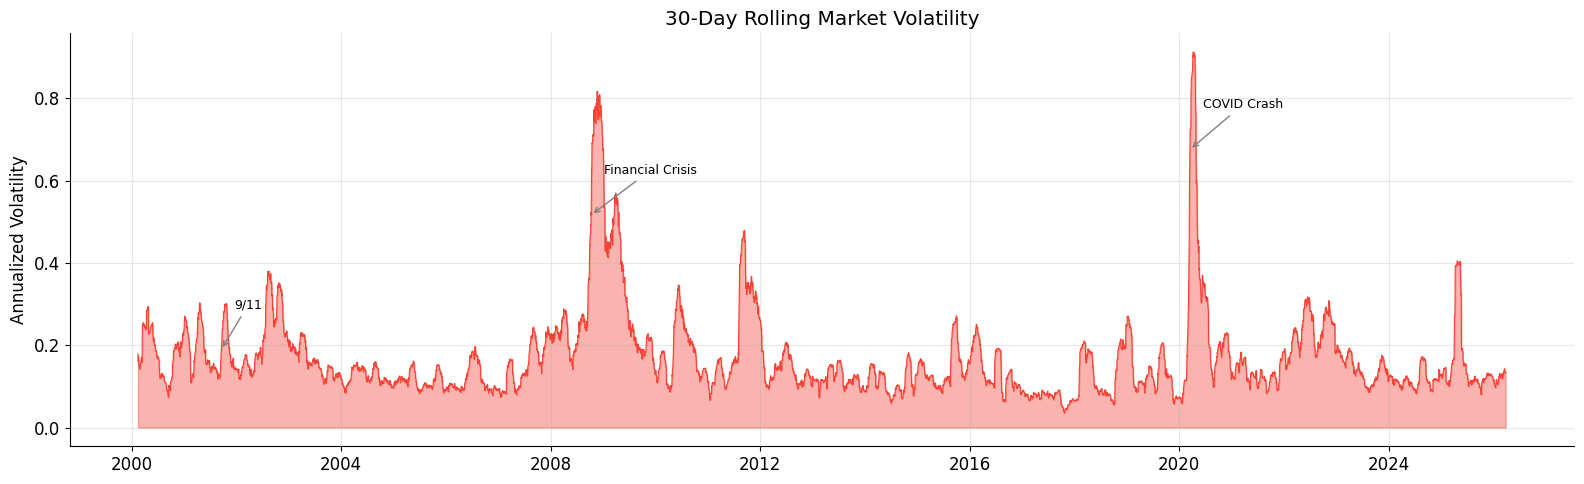

In [11]:
# 30-day rolling volatility (annualized)
rolling_vol = market_return.rolling(30).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(rolling_vol.index, 0, rolling_vol.values, alpha=0.4, color=RED)
ax.plot(rolling_vol.index, rolling_vol.values, color=RED, linewidth=0.8)
ax.set_ylabel("Annualized Volatility")
ax.set_title("30-Day Rolling Market Volatility")

# Annotate major crashes
events = {
    "2001-09-17": "9/11",
    "2008-10-10": "Financial Crisis",
    "2020-03-16": "COVID Crash",
}
for date_str, label in events.items():
    date = pd.to_datetime(date_str)
    if date in rolling_vol.index:
        ax.annotate(label, xy=(date, rolling_vol.loc[date]),
                    xytext=(date + timedelta(days=90), rolling_vol.loc[date] + 0.1),
                    fontsize=9, arrowprops=dict(arrowstyle="->", color="gray"))

plt.tight_layout()
plt.show()

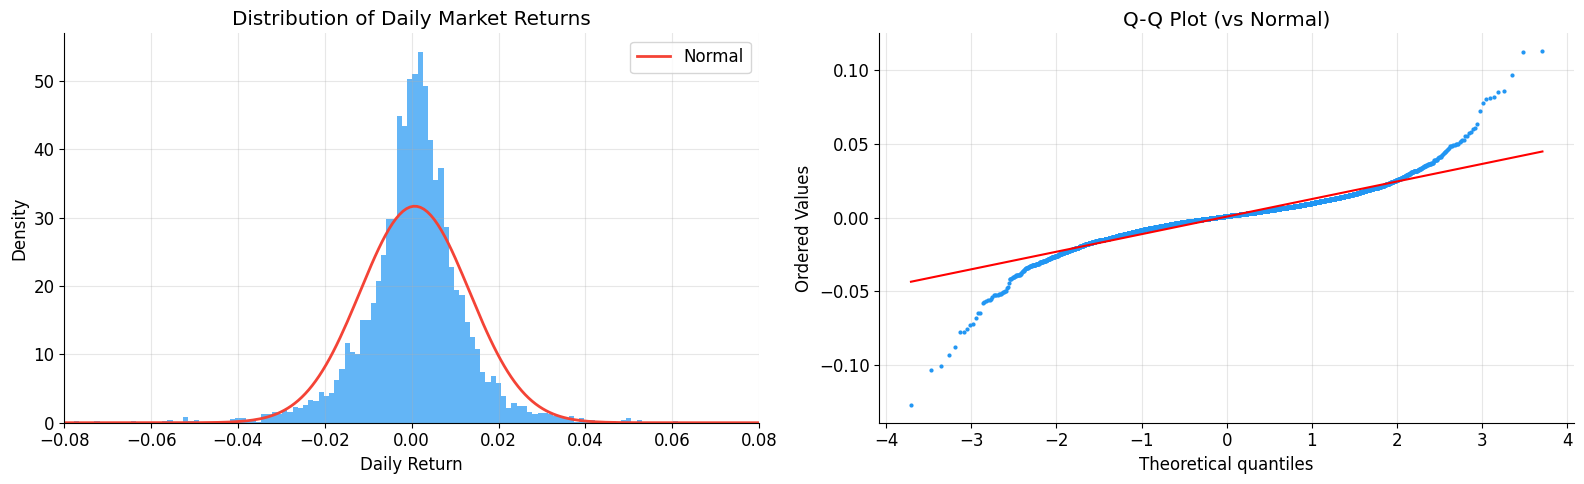

Mean daily return: 0.00071
Std daily return:  0.01259
Skewness: -0.184
Kurtosis: 10.880 (normal = 0)


In [12]:
# Distribution of daily returns
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

returns_clean = market_return.dropna()

axes[0].hist(returns_clean, bins=200, color=BLUE, alpha=0.7, edgecolor="none", density=True)
axes[0].set_xlabel("Daily Return")
axes[0].set_ylabel("Density")
axes[0].set_title("Distribution of Daily Market Returns")
axes[0].set_xlim(-0.08, 0.08)

# Normal overlay
x = np.linspace(-0.08, 0.08, 200)
from scipy.stats import norm
axes[0].plot(x, norm.pdf(x, returns_clean.mean(), returns_clean.std()),
             color=RED, linewidth=2, label="Normal")
axes[0].legend()

# QQ plot
from scipy.stats import probplot
probplot(returns_clean, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot (vs Normal)")
axes[1].get_lines()[0].set_color(BLUE)
axes[1].get_lines()[0].set_markersize(2)

plt.tight_layout()
plt.show()

print(f"Mean daily return: {returns_clean.mean():.5f}")
print(f"Std daily return:  {returns_clean.std():.5f}")
print(f"Skewness: {returns_clean.skew():.3f}")
print(f"Kurtosis: {returns_clean.kurtosis():.3f} (normal = 0)")

The heavy tails (excess kurtosis) and negative skew are classic features of stock returns — extreme negative days are more common than a normal distribution predicts.

---

## 5. Top & Bottom Performers

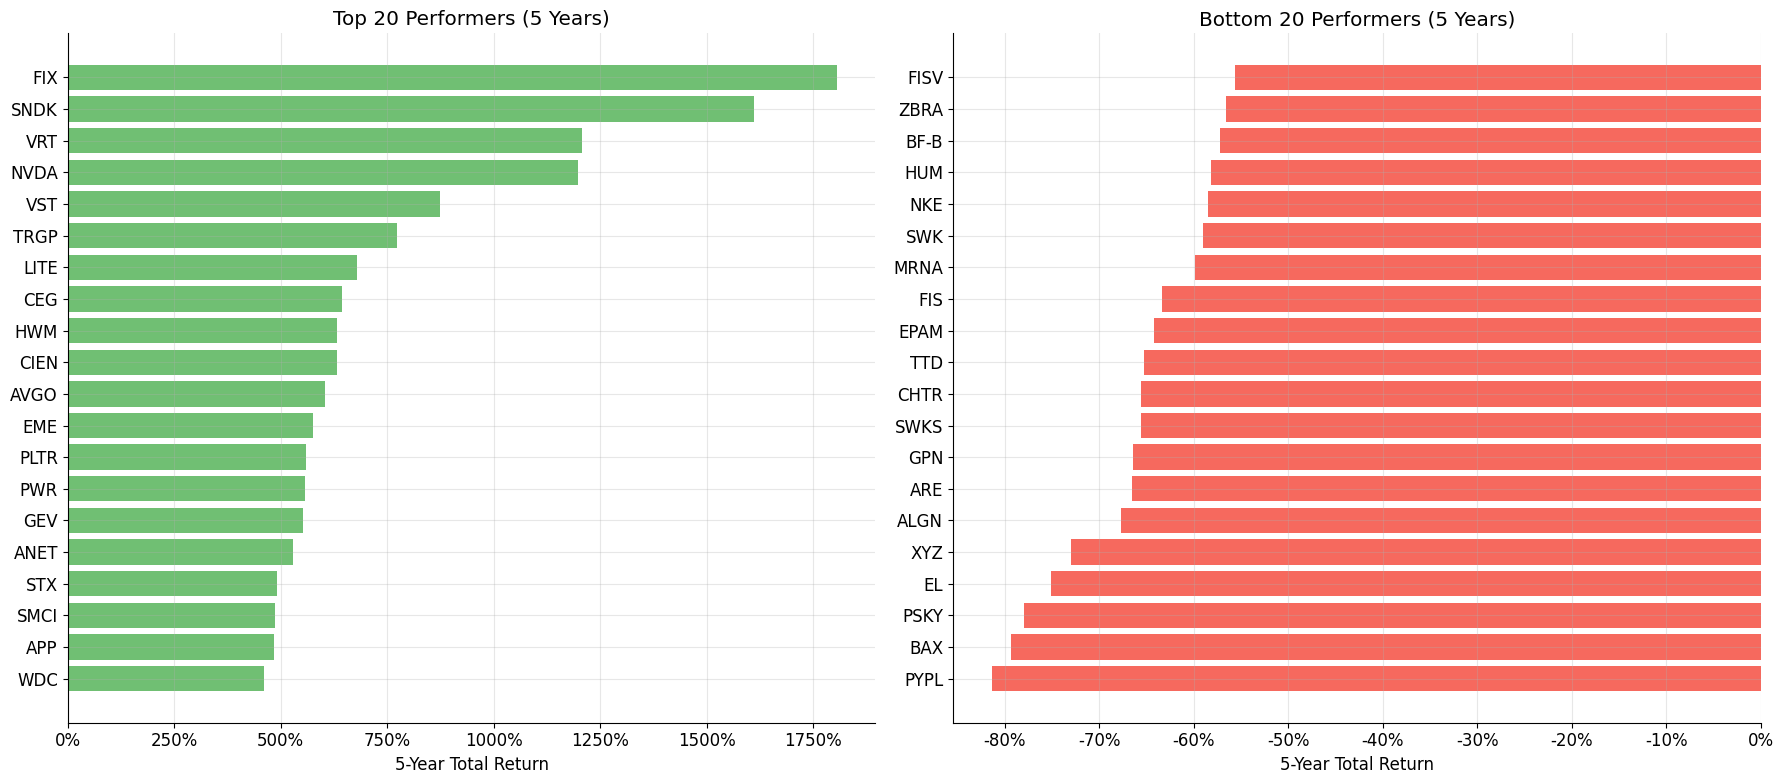

In [13]:
# Total return per stock (last 5 years)
recent = stocks[stocks["date"] >= stocks["date"].max() - timedelta(days=5*365)]

total_return = recent.groupby("symbol").apply(
    lambda g: (g["close"].iloc[-1] / g["close"].iloc[0] - 1) if len(g) > 100 else np.nan
).dropna().sort_values(ascending=False)

top20 = total_return.head(20)
bottom20 = total_return.tail(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].barh(range(len(top20)), top20.values, color=GREEN, alpha=0.8)
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20.index)
axes[0].set_xlabel("5-Year Total Return")
axes[0].set_title("Top 20 Performers (5 Years)")
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

axes[1].barh(range(len(bottom20)), bottom20.values, color=RED, alpha=0.8)
axes[1].set_yticks(range(len(bottom20)))
axes[1].set_yticklabels(bottom20.index)
axes[1].set_xlabel("5-Year Total Return")
axes[1].set_title("Bottom 20 Performers (5 Years)")
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

plt.tight_layout()
plt.show()

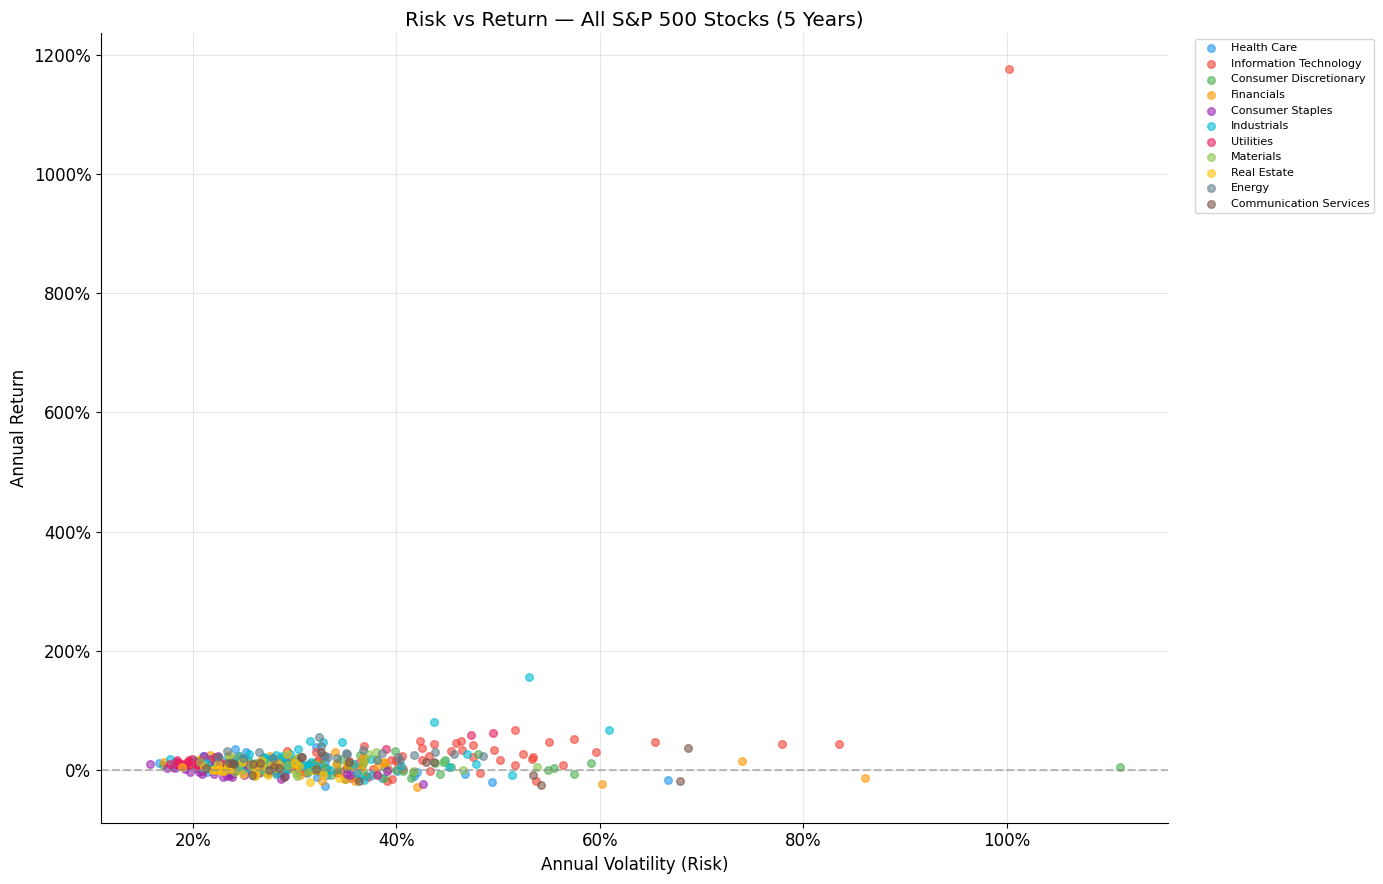

In [14]:
# Risk-Return scatter (5 years)
stock_stats = recent.groupby("symbol")["close"].apply(
    lambda g: pd.Series({
        "annual_return": (g.iloc[-1] / g.iloc[0]) ** (252 / len(g)) - 1 if len(g) > 100 else np.nan,
        "annual_vol": g.pct_change().std() * np.sqrt(252)
    })
).unstack()
stock_stats = stock_stats.dropna()
stock_stats = stock_stats.merge(companies[["symbol", "sector"]], on="symbol", how="left")

fig, ax = plt.subplots(figsize=(14, 9))

sectors = stock_stats["sector"].unique()
for i, sector in enumerate(sectors):
    mask = stock_stats["sector"] == sector
    ax.scatter(stock_stats.loc[mask, "annual_vol"],
               stock_stats.loc[mask, "annual_return"],
               c=COLORS[i % len(COLORS)], label=sector, alpha=0.6, s=30)

ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Annual Volatility (Risk)")
ax.set_ylabel("Annual Return")
ax.set_title("Risk vs Return — All S&P 500 Stocks (5 Years)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout()
plt.show()

---

## 6. Technical Indicators (AAPL Example)

In [15]:
# Pick AAPL for technical analysis — last 2 years
ticker = "AAPL"
cutoff = stocks["date"].max() - timedelta(days=2*365)
aapl = stocks[(stocks["symbol"] == ticker) & (stocks["date"] >= cutoff)].copy()

# Moving averages
aapl["SMA_20"] = aapl["close"].rolling(20).mean()
aapl["SMA_50"] = aapl["close"].rolling(50).mean()
aapl["SMA_200"] = aapl["close"].rolling(200).mean()

# RSI (14-day)
delta = aapl["close"].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
rs = gain / loss
aapl["RSI"] = 100 - (100 / (1 + rs))

# Bollinger Bands
aapl["BB_mid"] = aapl["close"].rolling(20).mean()
bb_std = aapl["close"].rolling(20).std()
aapl["BB_upper"] = aapl["BB_mid"] + 2 * bb_std
aapl["BB_lower"] = aapl["BB_mid"] - 2 * bb_std

print(f"{ticker}: {len(aapl)} trading days")

AAPL: 502 trading days


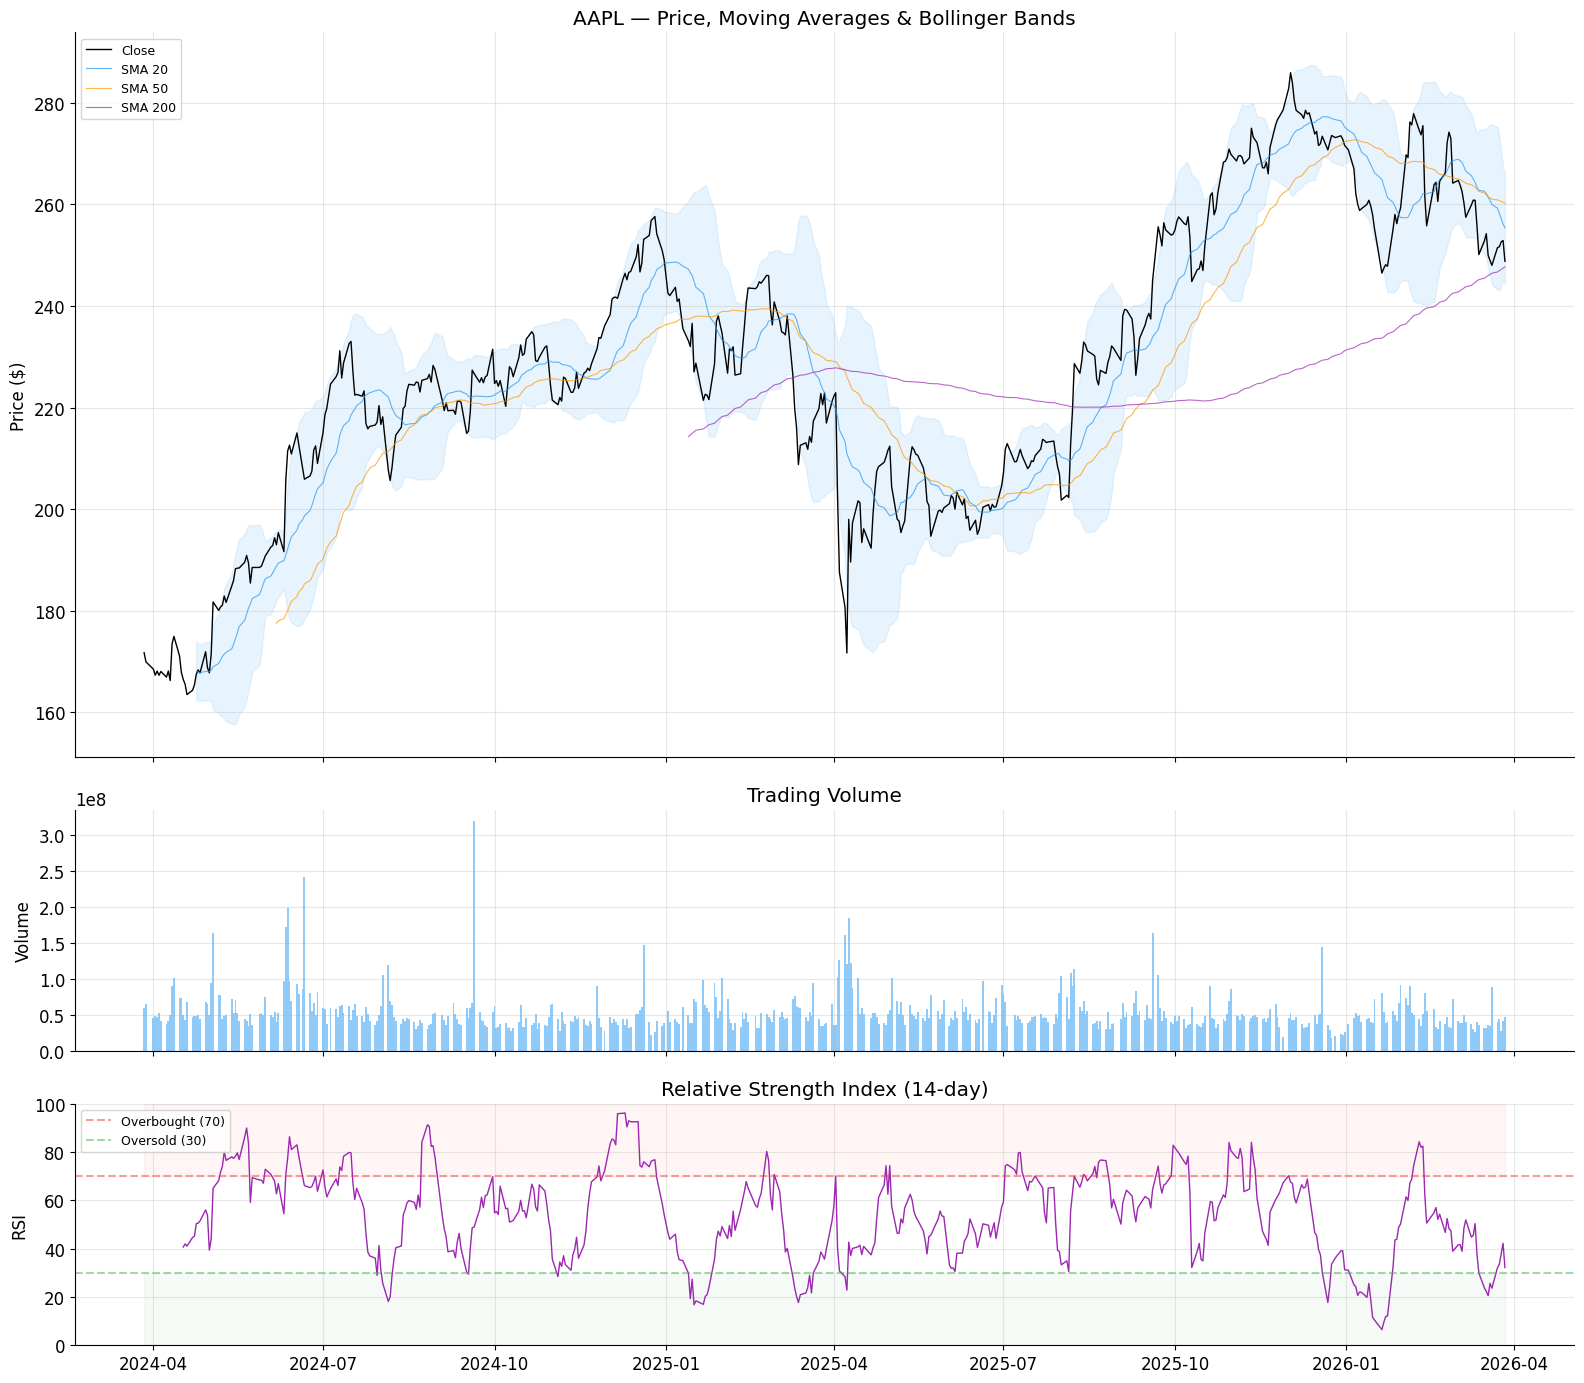

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1, 1]})

# Price + Moving Averages + Bollinger Bands
axes[0].plot(aapl["date"], aapl["close"], color="black", linewidth=1, label="Close")
axes[0].plot(aapl["date"], aapl["SMA_20"], color=BLUE, linewidth=0.8, alpha=0.7, label="SMA 20")
axes[0].plot(aapl["date"], aapl["SMA_50"], color=ORANGE, linewidth=0.8, alpha=0.7, label="SMA 50")
axes[0].plot(aapl["date"], aapl["SMA_200"], color=PURPLE, linewidth=0.8, alpha=0.7, label="SMA 200")
axes[0].fill_between(aapl["date"], aapl["BB_upper"], aapl["BB_lower"], alpha=0.1, color=BLUE)
axes[0].set_ylabel("Price ($)")
axes[0].set_title(f"{ticker} — Price, Moving Averages & Bollinger Bands")
axes[0].legend(loc="upper left", fontsize=9)

# Volume
axes[1].bar(aapl["date"], aapl["volume"], width=1, color=BLUE, alpha=0.5)
axes[1].set_ylabel("Volume")
axes[1].set_title("Trading Volume")

# RSI
axes[2].plot(aapl["date"], aapl["RSI"], color=PURPLE, linewidth=1)
axes[2].axhline(y=70, color=RED, linestyle="--", alpha=0.5, label="Overbought (70)")
axes[2].axhline(y=30, color=GREEN, linestyle="--", alpha=0.5, label="Oversold (30)")
axes[2].fill_between(aapl["date"], 70, 100, alpha=0.05, color=RED)
axes[2].fill_between(aapl["date"], 0, 30, alpha=0.05, color=GREEN)
axes[2].set_ylabel("RSI")
axes[2].set_title("Relative Strength Index (14-day)")
axes[2].set_ylim(0, 100)
axes[2].legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

---

## 7. LSTM Neural Network — Stock Price Prediction

We'll use an LSTM (Long Short-Term Memory) network to predict the **next-day closing price** using the previous 60 days of data. This is a sequence-to-one regression problem.

**Important disclaimer:** This is for educational purposes. Stock prices are notoriously difficult to predict, and this model should not be used for actual trading.

In [17]:
# Prepare data for LSTM — using AAPL
aapl_full = stocks[stocks["symbol"] == "AAPL"].sort_values("date").copy()
prices = aapl_full["close"].values.reshape(-1, 1)

# Scale to [0, 1]
scaler = MinMaxScaler()
prices_scaled = scaler.fit_transform(prices)

# Create sequences: use last 60 days to predict next day
SEQ_LEN = 60

X, y = [], []
for i in range(SEQ_LEN, len(prices_scaled)):
    X.append(prices_scaled[i - SEQ_LEN:i, 0])
    y.append(prices_scaled[i, 0])

X = np.array(X)
y = np.array(y)

# Reshape for LSTM: (samples, timesteps, features)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Train/test split — last 252 trading days (~1 year) as test
split = len(X) - 252
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Sequence length: {SEQ_LEN} days")
print(f"Train: {X_train.shape[0]:,} sequences")
print(f"Test:  {X_test.shape[0]:,} sequences")

Sequence length: 60 days
Train: 6,286 sequences
Test:  252 sequences


In [18]:
# Build LSTM model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.summary()

2026-03-29 17:57:35.785094: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Train
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - loss: 0.0025 - val_loss: 6.0920e-04
Epoch 2/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - loss: 3.9559e-04 - val_loss: 5.7804e-04
Epoch 3/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - loss: 3.1579e-04 - val_loss: 0.0036
Epoch 4/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - loss: 2.5468e-04 - val_loss: 5.1337e-04
Epoch 5/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - loss: 2.5104e-04 - val_loss: 0.0020
Epoch 6/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - loss: 2.3049e-04 - val_loss: 0.0036
Epoch 7/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - loss: 2.2998e-04 - val_loss: 0.0018
Epoch 8/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - loss: 2.3893e-04 - val_loss: 0.0011
Epoch 9/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - loss: 2.3575e-04 - val_loss: 0.0023


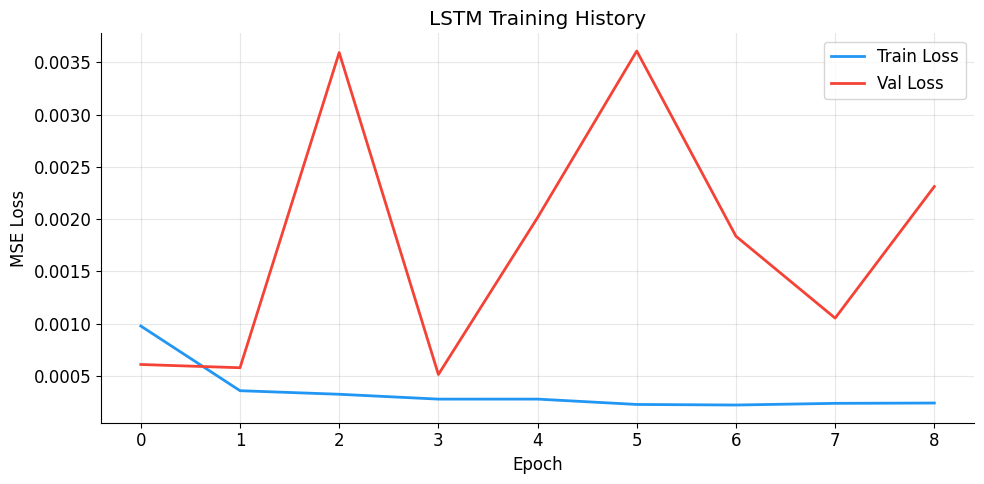

In [20]:
# Training history
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history["loss"], label="Train Loss", color=BLUE, linewidth=2)
ax.plot(history.history["val_loss"], label="Val Loss", color=RED, linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("LSTM Training History")
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
# Predict and inverse transform
y_pred_scaled = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled).flatten()
y_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Metrics
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mae = mean_absolute_error(y_actual, y_pred)
mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100

print(f"Test Set Metrics:")
print(f"  RMSE: ${rmse:.2f}")
print(f"  MAE:  ${mae:.2f}")
print(f"  MAPE: {mape:.2f}%")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
Test Set Metrics:
  RMSE: $10.41
  MAE:  $8.13
  MAPE: 3.39%


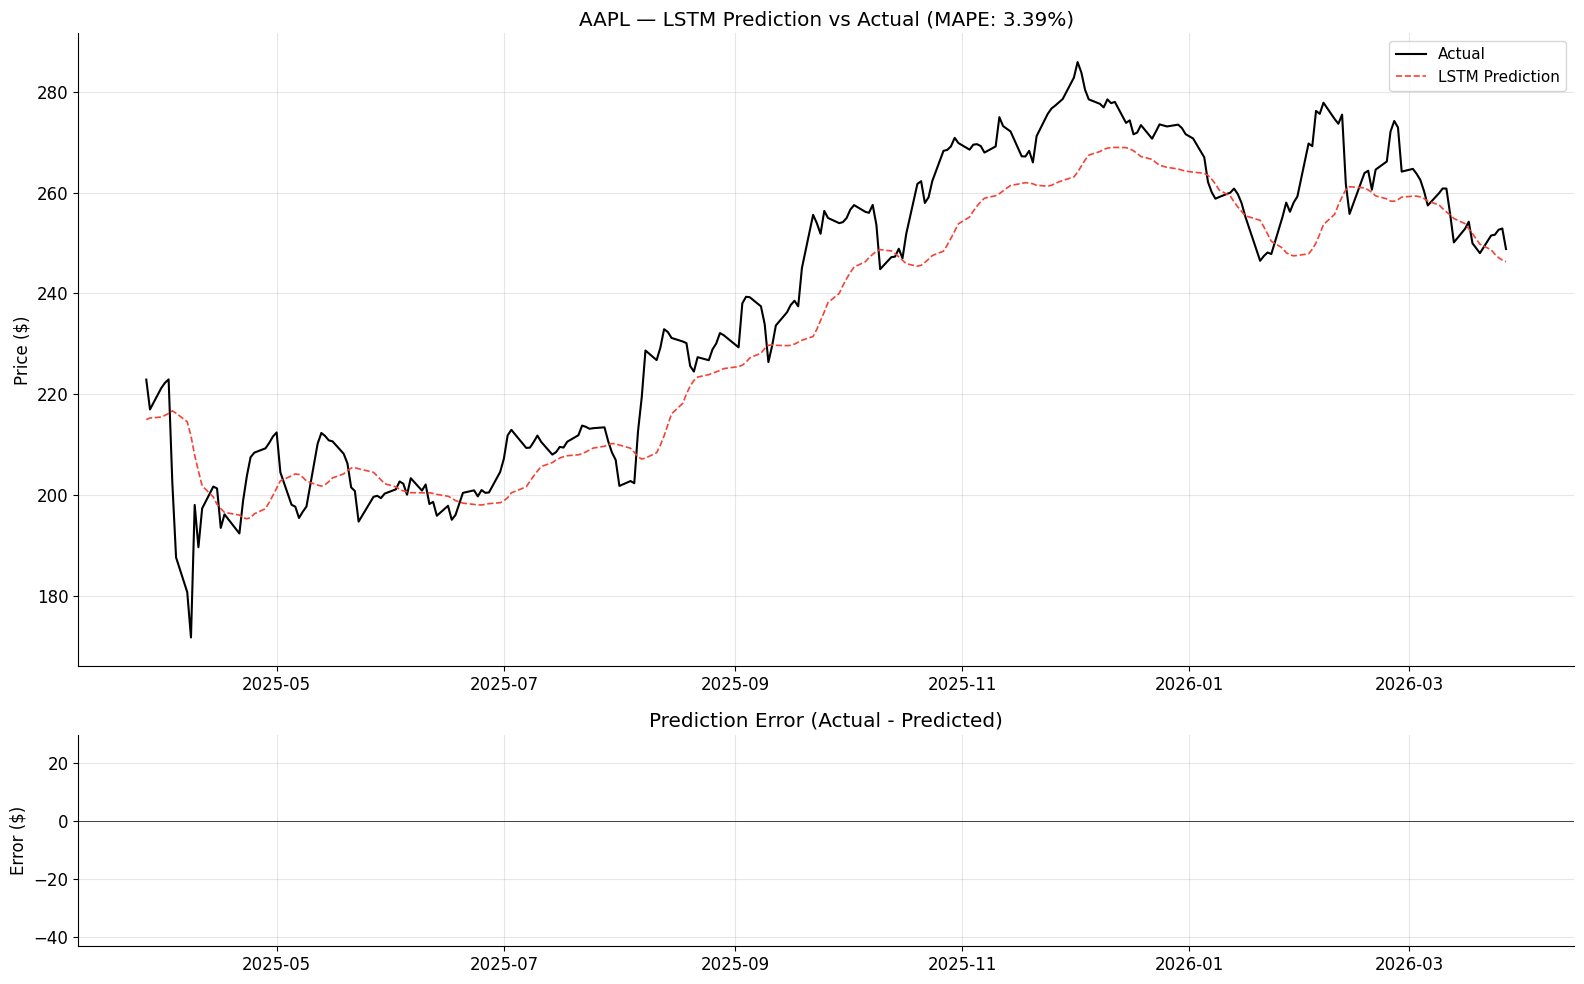

In [22]:
# Plot predictions vs actual
test_dates = aapl_full["date"].values[-(len(y_actual)):]

fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={"height_ratios": [3, 1]})

axes[0].plot(test_dates, y_actual, color="black", linewidth=1.5, label="Actual")
axes[0].plot(test_dates, y_pred, color=RED, linewidth=1.2, linestyle="--", label="LSTM Prediction")
axes[0].set_ylabel("Price ($)")
axes[0].set_title(f"AAPL — LSTM Prediction vs Actual (MAPE: {mape:.2f}%)")
axes[0].legend(fontsize=11)

# Error plot
error = y_actual - y_pred
axes[1].bar(test_dates, error, width=1, color=BLUE, alpha=0.5)
axes[1].axhline(y=0, color="black", linewidth=0.5)
axes[1].set_ylabel("Error ($)")
axes[1].set_title("Prediction Error (Actual - Predicted)")

plt.tight_layout()
plt.show()

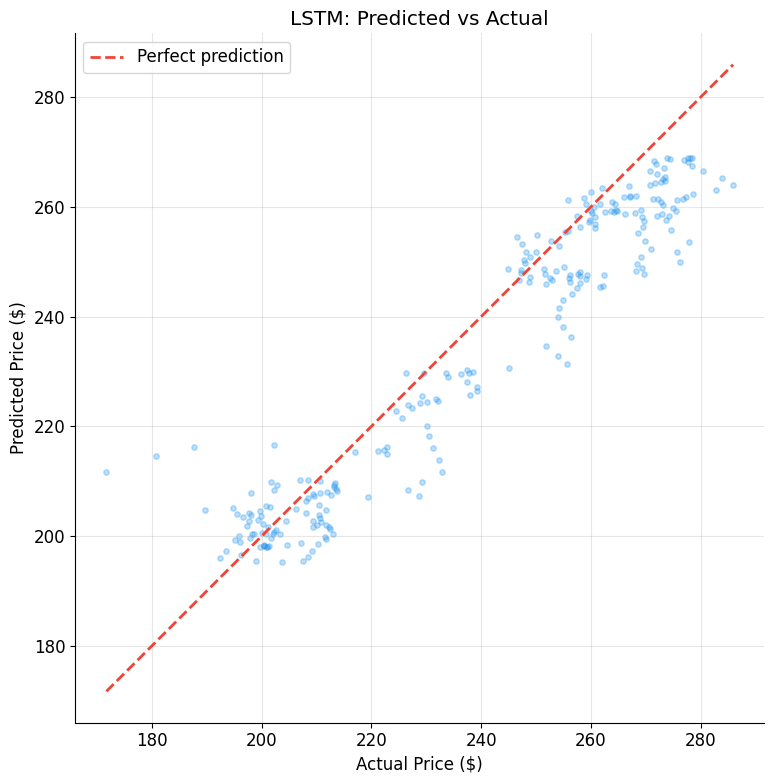

In [23]:
# Scatter: predicted vs actual
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_actual, y_pred, alpha=0.3, s=15, color=BLUE)
min_val = min(y_actual.min(), y_pred.min())
max_val = max(y_actual.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], color=RED, linewidth=2, linestyle="--", label="Perfect prediction")
ax.set_xlabel("Actual Price ($)")
ax.set_ylabel("Predicted Price ($)")
ax.set_title("LSTM: Predicted vs Actual")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Key Takeaways

**Market insights:**
- Stock returns have fat tails and negative skew — extreme drops are more frequent than normal distributions predict
- Sector correlations increase during crises (diversification breaks down when you need it most)
- Technology has dominated the last decade, but Energy led in the 2000s

**LSTM model:**
- The LSTM captures the general trend well but struggles with sudden moves
- A low MAPE doesn't mean the model is useful for trading — it mostly learns to predict "tomorrow ≈ today"
- For actual forecasting, you'd need returns prediction (not price), additional features (volume, sentiment, macro), and proper walk-forward validation

**This notebook demonstrates the techniques, not a trading strategy.**